# Modelling

Initial setup for modelling with randomforest, histgradientboosting and xgboost.

Data output:
* [classifier.joblib](../data_generated/classifier.joblib) Trained model
* [cv_best_by_model.json](../data_generated/cv_best_by_model.json) best parameters


In [1]:
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import pandas as pd
from joblib import dump
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import mnk.substrat as subkartimport mnk

## Terrain features

In [2]:
res = subkart.features.RESOLUTION

In [3]:
gdf_sea_map = mnk.sources.sea_map_basisdata(
    #["Oslo", "Ostfold", "Akershus", "Buskerud", "Vestfold", "Rogaland", "Vestland", "More_og_Romsdal", "Trondelag"]
)
crs = gdf_sea_map.crs

Reading preprocessed depth training data for all fylker.


In [4]:
gdf_sea_map = subkart.features.depth_preprocess(gdf_sea_map)
transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map, res=res)

All depth features already present, skipping preprocessing.


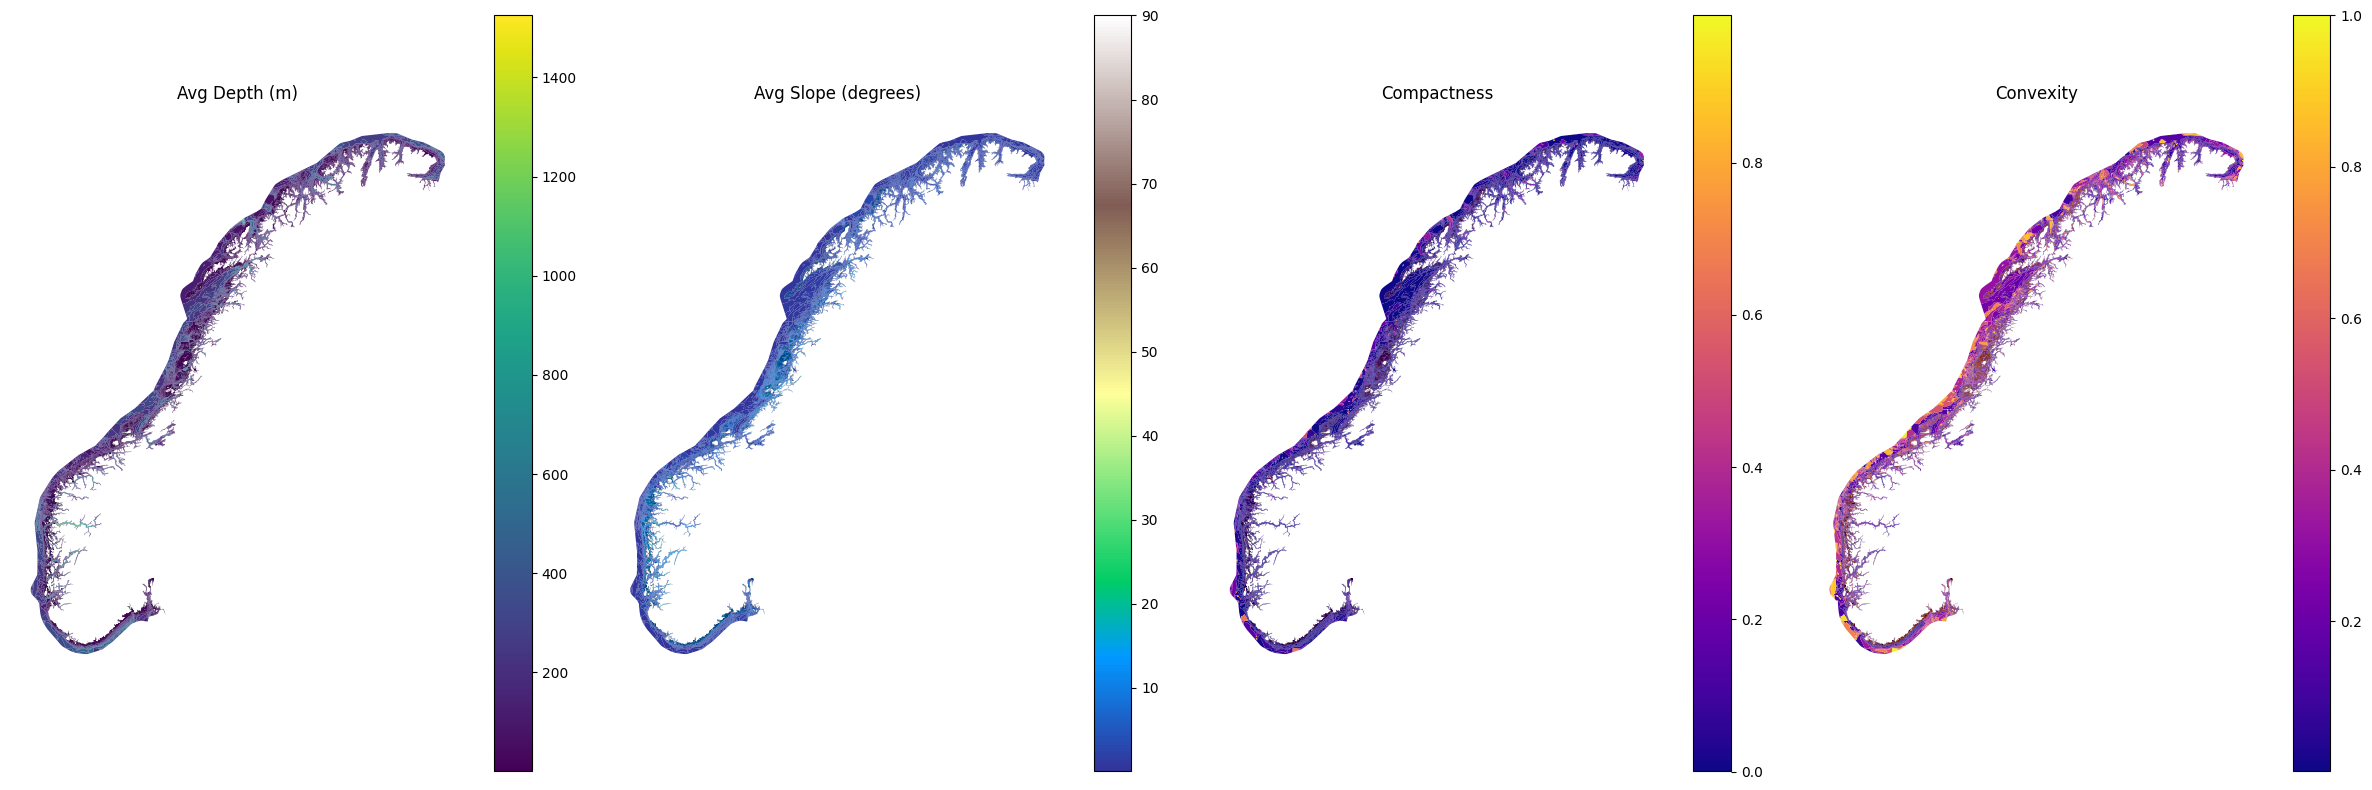

In [5]:
subkart.plot.terrain_features(gdf_sea_map)

## DEM 50

https://kartkatalog.geonorge.no/metadata/dybdedata-terrengmodeller-50-meters-grid/67a3a191-49cc-45bc-baf0-eaaf7c513549

In [6]:
dem = mnk.sources.dem_data()

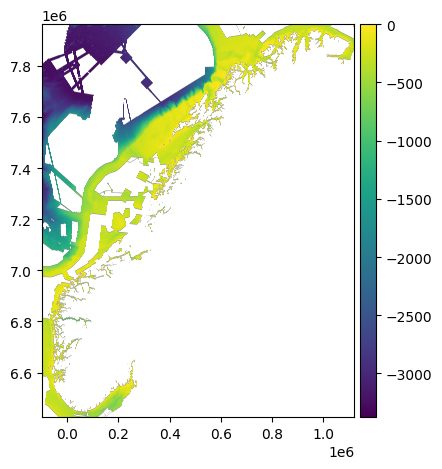

In [7]:
dem = dem.crop(bounds)
dem = subkart.utils.resample_dem(dem, out_shape, transform, crs)
dem.plot()

### Wave exposure features



In [8]:
bolge = mnk.sources.bolge_exposure()


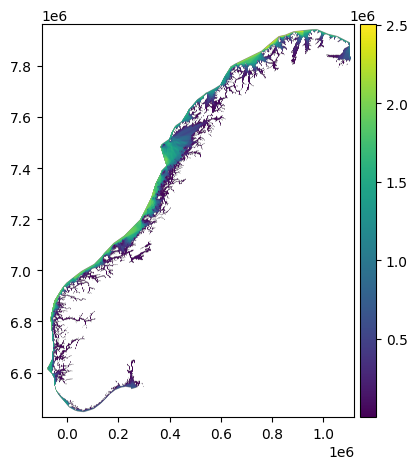

In [9]:
bolge = bolge.reproject(
    crs=crs, res=res,
    bounds=dict(left=bounds[0], bottom=bounds[1], right=bounds[2], top=bounds[3])
)
bolge.plot()

In [ ]:
gdf_points = mnk.sources.depth_point_data()
print(f"Depth points: {len(gdf_points):,}")


## Dataset for labels

In [10]:
gdf_bunn_full = gpd.read_parquet(
    "gs://niva-geodata/MarintNaturKart/results/nisjedata-substrat-klassifisering_norge_latest_25833.geo.parquet"
)
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

gdf_bunn_full = gdf_bunn_full.to_crs(crs)
bunn_raster, valid_bunn = subkart.labelling.rasterize_bunn_type(gdf_bunn_full, out_shape=out_shape, transform=transform)
del gdf_bunn_full

## Training

In [11]:
X, valid, out_shape, transform = subkart.features.build(
    dem, gdf_sea_map, bolge, valid_bunn, res=res, dtype=np.float32,
    gdf_points=gdf_points,
)

Computing interpolated depth raster...


Preparing sea_avg_depth...


Preparing sea_avg_slope...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_compactness...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_convexity...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing wave exposure...


Stacking feature arrays...


In [12]:
y = bunn_raster[valid]  # labels: {0,1,2}

classes = np.array(list(subkart.labelling.BUNNTYPE_MAPPING.values()), dtype=np.uint8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = {int(c): float(weight) for c, weight in zip(classes, weights)}
print("Class weights:", class_weights)

# Extract geographic coordinates for each valid pixel (needed for spatial CV
# and for the spatial performance analysis in 02_performance.ipynb)
rows, cols = np.where(valid)
xs, ys = rasterio.transform.xy(transform, rows, cols)
coords = np.column_stack([xs, ys])

# Assign marine vanntyper Region (N/S/M/H/G/B) to each sample
region_labels = subkart.training.assign_region_labels(coords, crs=str(crs))
print("Region distribution:", {r: int(c) for r, c in zip(*np.unique(region_labels, return_counts=True))})

# Train/validation split — keep coords and region_labels aligned with X and y
X_train, X_val, y_train, y_val, coords_train, coords_val, region_labels_train, region_labels_val = train_test_split(
    X, y, coords, region_labels, test_size=0.2, random_state=42, stratify=y
)

# Per-sample weights based on class (class 2 fastbunn gets higher weight since it is rare)
sample_weight_train = np.array([class_weights[int(c)] for c in y_train])


Class weights: {0: 0.5534838725633138, 1: 2.1697917089426717, 2: 1.3653948201055048}


Region distribution: {'B': 1187842, 'G': 1804812, 'H': 683635, 'M': 1405867, 'N': 418167, 'S': 265407, 'unknown': 8268}


### Baseline

Train a quick baseline for each model

In [13]:
baseline_models = [
    XGBClassifier(
        num_class=len(classes),
        n_estimators=300,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=2,
        tree_method="hist",
    ),
    #HistGradientBoostingClassifier(random_state=42, class_weight=class_weights),
    #RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42),
]

score = 0
for base_model in baseline_models:
    m = Pipeline([("model", base_model)])
    m.fit(X_train, y_train, model__sample_weight=sample_weight_train)
    val_score = m.score(X_val, y_val)
    print(f"Baseline {type(base_model).__name__} - " f"Train: {m.score(X_train, y_train):.4f}, Val: {val_score:.4f}")
    if val_score > score:
        score = val_score
        classifier = base_model

Baseline XGBClassifier - Train: 0.7417, Val: 0.7388


## Random Search

Search through hyperparameters for each model, this can take some time

In [14]:

classifier, search_results = subkart.training.optimize_xgboost_hyperparameters(
    X_train, y_train, X_val, y_val, classes,
    class_weights=class_weights,
    region_labels=region_labels_train,
)


Starting search around existing parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


  6619 samples with unknown region included in all training folds, excluded from test folds.


Samples per region: {'B': 950219, 'G': 1443943, 'H': 546977, 'M': 1125038, 'N': 334404, 'S': 211998, 'unknown': 6619}

Starting randomized search with 50 iterations, spatial Leave-One-Region-Out (6 regions: ['B', 'G', 'H', 'M', 'N', 'S'])...
Fitting 6 folds for each of 50 candidates, totalling 300 fits


[CV] END colsample_bytree=1.0, gamma=0.08263346953150125, learning_rate=0.14187636880894328, max_depth=5, min_child_weight=8, n_estimators=478, reg_alpha=0.3974313630683448, reg_lambda=1.0165663513708072, subsample=0.9261845713819337; total time=41.2min
[CV] END colsample_bytree=1.0, gamma=0.23610746258097465, learning_rate=0.1543513095125962, max_depth=10, min_child_weight=3, n_estimators=606, reg_alpha=1.4434590423297464, reg_lambda=1.7079547592468671, subsample=0.7024273291045297; total time=57.1min


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


...

[CV] END colsample_bytree=1.0, gamma=0.331261142176991, learning_rate=0.17740532913072932, max_depth=10, min_child_weight=6, n_estimators=455, reg_alpha=1.135400655639983, reg_lambda=1.0939398773666758, subsample=0.9369139098379995; total time=59.4min
[CV] END colsample_bytree=1.0, gamma=0.48830747791632645, learning_rate=0.18932444159818776, max_depth=9, min_child_weight=1, n_estimators=475, reg_alpha=0.2897897441824462, reg_lambda=2.468358280832689, subsample=0.9942601816442402; total time=35.6min
[CV] END colsample_bytree=1.0, gamma=0.38993777292881193, learning_rate=0.21704379753851455, max_depth=7, min_child_weight=1, n_estimators=453, reg_alpha=1.2128581193191799, reg_lambda=1.027591154849889, subsample=0.6405886171464129; total time=39.5min
[CV] END colsample_bytree=1.0, gamma=0.017971136898371043, learning_rate=0.19587176217589522, max_depth=10, min_child_weight=6, n_estimators=407, reg_alpha=0.06100049987809886, reg_lambda=1.1120445662476433, subsample=0.9290402242638633; tota

[CV] END colsample_bytree=1.0, gamma=0.22962444598293358, learning_rate=0.18004503333668265, max_depth=7, min_child_weight=6, n_estimators=607, reg_alpha=1.4439975445336495, reg_lambda=3.8156581270472505, subsample=0.6003115063364058; total time=62.9min
[CV] END colsample_bytree=1.0, gamma=0.0002601884976579094, learning_rate=0.1823082627601003, max_depth=7, min_child_weight=7, n_estimators=547, reg_alpha=1.0214946051551315, reg_lambda=2.252233009446337, subsample=0.6888431241882922; total time=43.9min
[CV] END colsample_bytree=1.0, gamma=0.08747746354796809, learning_rate=0.2578602011995323, max_depth=8, min_child_weight=1, n_estimators=351, reg_alpha=1.9925073995158487, reg_lambda=3.896258053866381, subsample=0.8233173814428391; total time=28.8min
[CV] END colsample_bytree=1.0, gamma=0.27640998845395387, learning_rate=0.17558121723773584, max_depth=6, min_child_weight=3, n_estimators=362, reg_alpha=0.16318836080048071, reg_lambda=1.0155545883219603, subsample=0.8511577659794545; tota

[CV] END colsample_bytree=1.0, gamma=0.06974693032602092, learning_rate=0.17505735782422618, max_depth=10, min_child_weight=3, n_estimators=404, reg_alpha=1.9664617716135764, reg_lambda=2.40028867974394, subsample=0.9439761626945282; total time=54.6min
[CV] END colsample_bytree=1.0, gamma=0.0002601884976579094, learning_rate=0.1823082627601003, max_depth=7, min_child_weight=7, n_estimators=547, reg_alpha=1.0214946051551315, reg_lambda=2.252233009446337, subsample=0.6888431241882922; total time=47.7min
[CV] END colsample_bytree=1.0, gamma=0.35608961067376793, learning_rate=0.16846989049961603, max_depth=9, min_child_weight=4, n_estimators=484, reg_alpha=1.4418798485042585, reg_lambda=1.9241823755571676, subsample=0.8170160922219598; total time=48.6min
[CV] END colsample_bytree=1.0, gamma=0.3442499503826832, learning_rate=0.14698323146101325, max_depth=6, min_child_weight=1, n_estimators=588, reg_alpha=0.5004857963291907, reg_lambda=2.6476799941183615, subsample=0.8858383690800249; total

[CV] END colsample_bytree=1.0, gamma=0.325742385928894, learning_rate=0.16480212318520945, max_depth=9, min_child_weight=2, n_estimators=602, reg_alpha=0.1888859215118568, reg_lambda=3.0490203202490704, subsample=0.6284754593840917; total time=31.7min



Optimization complete!
Best CV score: 0.5909
CV train score: 0.7779
Train accuracy: 0.7424
Validation accuracy: 0.7393
Overfitting gap (train - val): 0.0030

Best parameters:
  colsample_bytree: 1.0
  gamma: 0.3442499503826832
  learning_rate: 0.14698323146101325
  max_depth: 6
  min_child_weight: 1
  n_estimators: 588
  reg_alpha: 0.5004857963291907
  reg_lambda: 2.6476799941183615
  subsample: 0.8858383690800249


In [ ]:
dump(classifier, subkart.utils.model_dir_path() / "classifier.joblib")

['/home/jovyan/marint-naturkart-niva/model/classifier.joblib']

## Detailed evaluation

Confusion matrix, feature importance, classification report, spatial performance, and
class-1-aware ("blanding" as a mixture of løsbunn/fastbunn) adjusted metrics, computed on the
validation set (`X_val`/`y_val`/`coords_val`/`region_labels_val`) built above.

## Hyperparameter search summary

In [13]:
model_dir = subkart.utils.model_dir_path()

with open(model_dir / "xgboost_results.json", encoding="utf-8") as f:
    xgb_results = json.load(f)

class_names = [subkart.evaluation.CLASS_NAMES[c] for c in classes]



In [14]:
scores = pd.Series(
    {
        "Best CV score": xgb_results["best_score"],
        "CV train score": xgb_results["cv_train_score"],
        "Train accuracy": xgb_results["train_score"],
        "Validation accuracy": xgb_results["val_score"],
        "Overfitting gap (train - val)": xgb_results["overfitting_gap"],
    },
    name="score",
).to_frame()
scores

,score
Best CV score,0.590876
CV train score,0.777868
Train accuracy,0.742357
Validation accuracy,0.739330
Overfitting gap (train - val),0.003027


In [15]:
print("Best XGBoost hyperparameters found:")
for param, value in xgb_results["best_params"].items():
    print(f"  {param}: {value}")

Best XGBoost hyperparameters found:
  colsample_bytree: 1.0
  gamma: 0.3442499503826832
  learning_rate: 0.14698323146101325
  max_depth: 6
  min_child_weight: 1
  n_estimators: 588
  reg_alpha: 0.5004857963291907
  reg_lambda: 2.6476799941183615
  subsample: 0.8858383690800249


## Precision and accuracy explained

Two of the most common classification metrics, applied to our 3-class bottom-type problem
(0 = løsbunn, 1 = blanding, 2 = fastbunn):

* **Accuracy** — the fraction of *all* predictions that are exactly correct:

  $$\text{Accuracy} = \frac{\text{correct predictions}}{\text{total predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

  Accuracy treats every class equally and every error equally. It can be misleading when
  classes are imbalanced, or — as here — when some errors matter less than others (see the
  "adjusted accuracy" section below).

* **Precision** (per class) — of everything the model *predicted* as a given class, the
  fraction that was actually that class:

  $$\text{Precision}_c = \frac{TP_c}{TP_c + FP_c}$$

  High precision for "fastbunn" means: when the model says a pixel is fastbunn, it usually is.
  Low precision means the model over-predicts that class (many false positives).

* **Recall** (per class, for reference) — of everything that *actually is* a given class, the
  fraction the model found:

  $$\text{Recall}_c = \frac{TP_c}{TP_c + FN_c}$$

Below we compute these directly from the validation confusion matrix so the definitions are
tied to concrete numbers for this model.

In [16]:
# Load classifier in case only evaluations are re-executed
classifier = subkart.utils.load_classifier()

In [17]:
y_val_pred = classifier.predict(X_val)

overall_accuracy = (y_val_pred == y_val).mean()
print(f"Overall accuracy: {overall_accuracy:.4f}  "
      f"({int((y_val_pred == y_val).sum())} / {len(y_val)} predictions correct)")

cm_counts = confusion_matrix(y_val, y_val_pred, labels=classes)
print("\nConfusion matrix (counts, rows=true, cols=predicted):")
print(pd.DataFrame(cm_counts, index=class_names, columns=class_names))


def print_worked_example(cm_counts, class_names, example_class_idx, display_name=None):
    """Print TP/FP/FN and the resulting precision/recall for one class, computed
    directly from the confusion matrix counts."""
    display_name = display_name or class_names[example_class_idx]
    tp = cm_counts[example_class_idx, example_class_idx]
    fp = cm_counts[:, example_class_idx].sum() - tp
    fn = cm_counts[example_class_idx, :].sum() - tp
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    print(f"\nWorked example for class '{display_name}':")
    print(f"  TP={tp}, FP={fp}, FN={fn}")
    print(f"  Precision = TP/(TP+FP) = {tp}/{tp + fp} = {precision:.4f}")
    print(f"  Recall    = TP/(TP+FN) = {tp}/{tp + fn} = {recall:.4f}")


# Worked examples: precision/recall for one class at a time, from the raw counts.
# "løsbunn" (class 0, soft bottom) is also commonly called "bløtbunn" in the field data.
print_worked_example(cm_counts, class_names, example_class_idx=0, display_name="bløtbunn (løsbunn)")
print_worked_example(cm_counts, class_names, example_class_idx=2)  # fastbunn

Overall accuracy: 0.7393  (853778 / 1154800 predictions correct)

Confusion matrix (counts, rows=true, cols=predicted):
          løsbunn  blanding  fastbunn
løsbunn    486205    105842    103426
blanding    16849    144058     16499
fastbunn    22427     35979    223515

Worked example for class 'bløtbunn (løsbunn)':
  TP=486205, FP=39276, FN=209268
  Precision = TP/(TP+FP) = 486205/525481 = 0.9253
  Recall    = TP/(TP+FN) = 486205/695473 = 0.6991

Worked example for class 'fastbunn':
  TP=223515, FP=119925, FN=58406
  Precision = TP/(TP+FP) = 223515/343440 = 0.6508
  Recall    = TP/(TP+FN) = 223515/281921 = 0.7928


## Confusion matrix and classification report

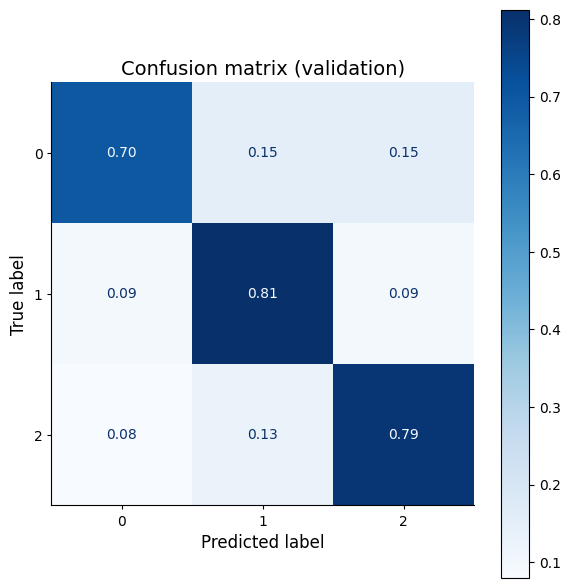

In [18]:
# Compute confusion matrix (normalized by true class)
cm = confusion_matrix(y_val, y_val_pred, labels=classes, normalize="true")
subkart.plot.confusion_matrix(cm, classes)

In [19]:
print("Classification report (validation):")
report_dict = classification_report(
    y_val,
    y_val_pred,
    labels=classes,
    target_names=class_names,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).T
report_df

Classification report (validation):


,precision,recall,f1-score,support
løsbunn,0.925257,0.699100,0.796435,6.954730e+05
blanding,0.503912,0.812024,0.621898,1.774060e+05
fastbunn,0.650812,0.792828,0.714835,2.819210e+05
accuracy,0.739330,0.739330,0.739330,7.393298e-01
macro avg,0.693327,0.767984,0.711056,1.154800e+06
weighted avg,0.793528,0.739330,0.749701,1.154800e+06


## Feature importance

dem_slope: mean=0.094208, std=0.000442
dem_depth: mean=0.093275, std=0.000422
wave_exposure: mean=0.067798, std=0.000310
sea_convexity: mean=0.049602, std=0.000237
dem_curvature: mean=0.047518, std=0.000179
sea_avg_slope: mean=0.047181, std=0.000252
sea_compactness: mean=0.036091, std=0.000259
sea_avg_depth: mean=0.026939, std=0.000184
is_dem: mean=0.002934, std=0.000058


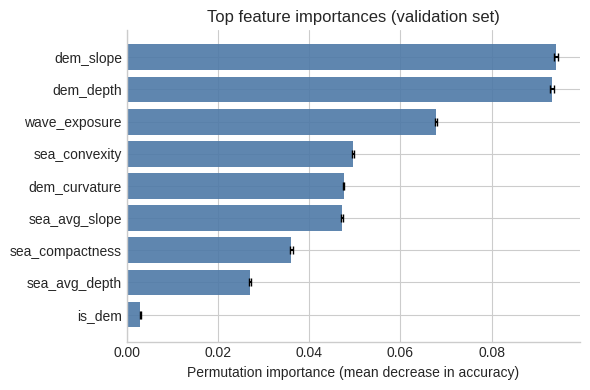

In [20]:
subkart.plot.feature_importance(classifier, X_val, y_val)

## Class-1-aware ("blanding") adjusted metrics

"Blanding" (class 1) is not an independent bottom type — it is a physical *mixture* of
løsbunn (0) and fastbunn (2). `subkart.utils.remap_prediction` even resolves "blanding"
pixels back to whichever pure class is more probable downstream. That means:

* Confusing **løsbunn ↔ blanding** or **blanding ↔ fastbunn** is a *mild* error: the pixel
  plausibly contains some of the predicted material.
* Confusing **løsbunn ↔ fastbunn** directly is a *severe* error: the model got the physical
  bottom type completely backwards.

Plain accuracy/precision/recall treat all three misclassification types identically. The
metrics below (`subkart.evaluation`) instead:

* **`adjusted_accuracy`** — accuracy where a løsbunn↔fastbunn flip costs a full error (1.0),
  but any error touching "blanding" only costs 0.25.
* **`tolerant_accuracy`** — fraction of predictions within one class of the truth (i.e. not a
  løsbunn↔fastbunn flip).
* **`severe_error_rate`** — fraction of predictions that *are* a direct løsbunn↔fastbunn flip.
* **Cohen's kappa (quadratic weighted)** — a standard ordinal-aware agreement statistic that
  penalizes distant errors (løsbunn↔fastbunn) more than adjacent ones, for comparison.

In [21]:
metrics = subkart.evaluation.summarize_metrics(y_val, y_val_pred)
metrics.to_frame(name="score")

,score
accuracy,0.739330
adjusted_accuracy,0.853096
tolerant_accuracy (±1 class),0.891017
severe_error_rate (løsbunn<->fastbunn),0.108983
cohen_kappa,0.576365
cohen_kappa (linear weighted),0.591777
cohen_kappa (quadratic weighted),0.604541


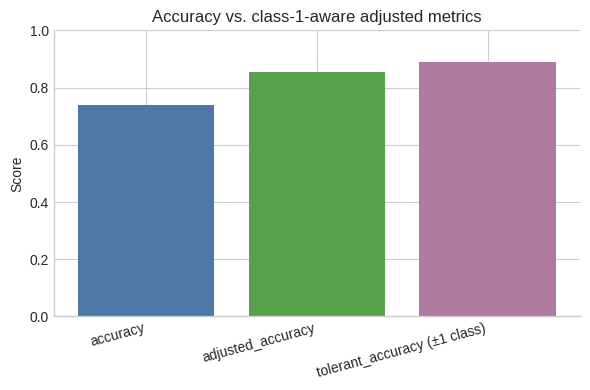

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
compare = metrics[["accuracy", "adjusted_accuracy", "tolerant_accuracy (±1 class)"]]
ax.bar(compare.index, compare.values, color=["#4e79a7", "#59a14f", "#af7aa1"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Accuracy vs. class-1-aware adjusted metrics")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Spatial performance

How does the model perform geographically? We plot validation errors on the map (split into
mild vs. severe, per the class-1-aware definition above), and break down accuracy and
adjusted accuracy by marine vanntyper region (N/S/M/H/G/B).

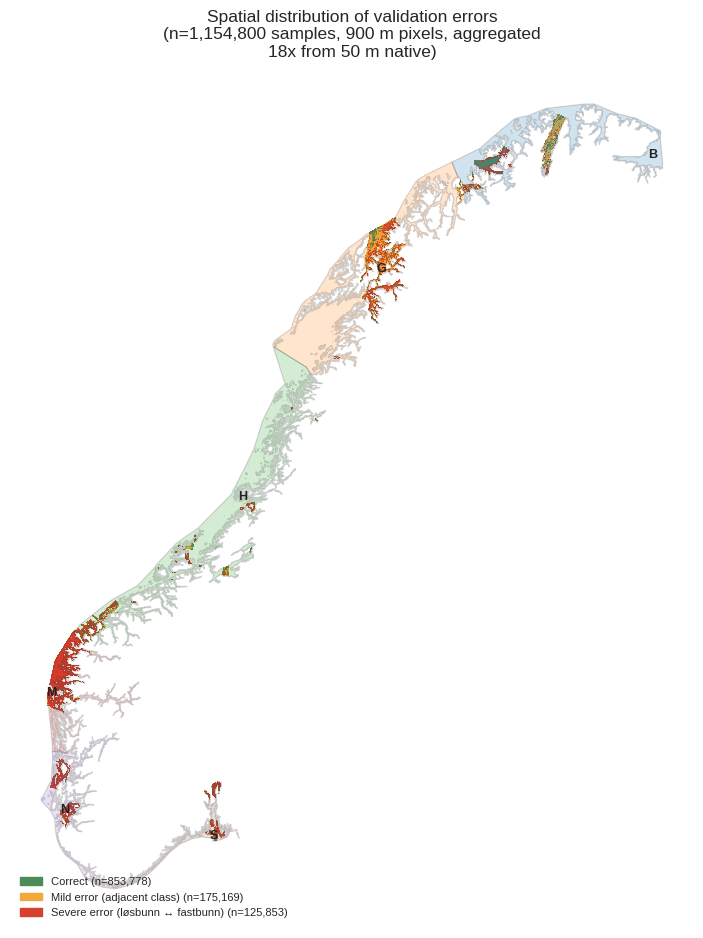

In [23]:
# Dissolved marine vanntyper region polygons, drawn as a light backdrop so errors can
# be related to region boundaries (reuses the same source as assign_region_labels above).
regions_gdf = (
    mnk.sources.marine_vanntyper()[["Region", "geometry"]]
    .dissolve(by="Region")
    .reset_index()
)

subkart.plot.spatial_errors(coords_val, y_val, y_val_pred, crs="EPSG:25833", region_gdf=regions_gdf)

In [24]:
region_df = subkart.evaluation.performance_by_region(y_val, y_val_pred, region_labels_val)
region_df

,region,n_samples,accuracy,adjusted_accuracy,severe_error_rate
0,B,237623,0.809850,0.924277,0.037581
1,G,360869,0.696025,0.888255,0.047668
2,H,136658,0.727290,0.847596,0.112302
3,M,280829,0.737933,0.771017,0.217955
4,N,83763,0.702685,0.782562,0.190812
5,S,53409,0.814170,0.856284,0.129679
6,unknown,1649,0.727107,0.814888,0.155852


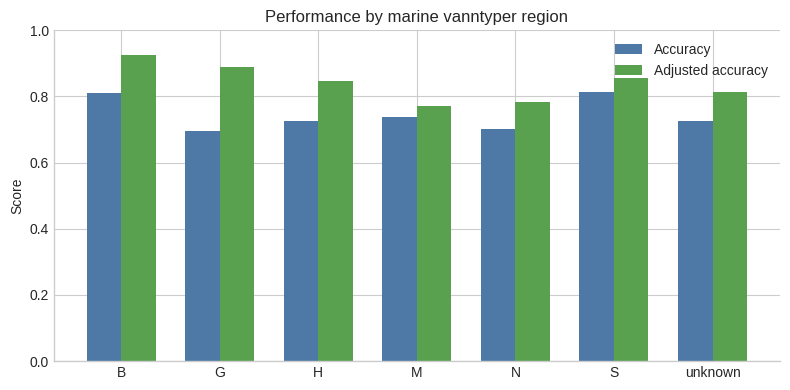

In [25]:
subkart.plot.region_performance(region_df)

## Summary

* Standard accuracy/precision/recall are reported above and computed directly from the
  validation confusion matrix.
* The class-1-aware adjusted accuracy and tolerant accuracy are consistently higher than plain
  accuracy, since they don't penalize "blanding" boundary errors as harshly as a genuine
  løsbunn↔fastbunn flip — which better reflects the real-world cost of these mistakes.
* The severe error rate (direct løsbunn↔fastbunn confusion) is a useful single number for
  tracking the "actually wrong" error rate across model iterations.
* Spatial and per-region breakdowns highlight whether errors (especially severe ones) cluster
  in particular geographic areas, which can point to missing features or under-represented
  training data in those regions.